# Comparative Simulation of PSO and ABC for Swarm UAV Path Planning in an Edge Computing Context

This notebook implements a comparative simulation between Particle Swarm Optimization (PSO) and Artificial Bee Colony (ABC) for swarm UAV path planning. The experiment compares both algorithms under different UAV and waypoint configurations.

The output consists of summary tables, trajectory figures, convergence curves, comparative plots, and raw simulation files for attachment.

## 1. Experimental Design

The simulated environment is a two-dimensional area with fixed circular obstacles. Each UAV moves from a start position to a goal position through intermediate waypoints. PSO and ABC search for the best waypoint configuration.

The objective function combines path length, obstacle collision penalty, inter-UAV separation penalty, and path smoothness penalty.

\[
J = L + P_{collision} + P_{separation} + P_{smoothness}
\]

Five scenarios are used.

| Scenario | Number of UAVs | Number of Waypoints |
|---|---:|---:|
| S1 | 1 | 1 |
| S2 | 1 | 3 |
| S3 | 3 | 1 |
| S4 | 3 | 3 |
| S5 | 5 | 3 |

## 2. References Used as Methodological Basis

1. ITU-T Recommendation Y.2060, *Overview of the Internet of Things*, 2012.
2. S. Lin, F. Li, X. Li, and Z. Yang, “Improved Artificial Bee Colony Algorithm Based on Multi-Strategy Synthesis for UAV Path Planning,” *IEEE Access*, 2022.
3. A. Sonny, Y. S. Reddy, and L. R. Cenkeramaddi, “Autonomous UAV Path Planning Using Modified PSO for UAV-Assisted Wireless Networks,” *IEEE Access*, 2023.
4. V. T. Hoang, M. D. Phung, T. H. Dinh, and Q. P. Ha, “Angle-Encoded Swarm Optimization for UAV Formation Path Planning,” 2018.

The implementation is a compact simulation model intended for laboratory comparison, not a full UAV flight dynamics model.

In [1]:
import os
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

OUTPUT_DIR = "uav_path_planning_outputs"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIGURE_DIR, exist_ok=True)

AREA_MIN = 0.0
AREA_MAX = 100.0

OBSTACLES = np.array([
    [32.0, 45.0, 10.0],
    [55.0, 58.0, 12.0],
    [70.0, 30.0, 9.0],
    [45.0, 22.0, 8.0]
], dtype=float)

SCENARIOS = [
    {"scenario": "S1", "num_uavs": 1, "num_waypoints": 1},
    {"scenario": "S2", "num_uavs": 1, "num_waypoints": 3},
    {"scenario": "S3", "num_uavs": 3, "num_waypoints": 1},
    {"scenario": "S4", "num_uavs": 3, "num_waypoints": 3},
    {"scenario": "S5", "num_uavs": 5, "num_waypoints": 3}
]

N_RUNS = 30
MAX_ITER = 100
POP_SIZE = 50
MIN_SEPARATION = 8.0

COLLISION_WEIGHT = 10000.0
SEPARATION_WEIGHT = 400.0
SMOOTHNESS_WEIGHT = 2.0

PSO_W = 0.72
PSO_C1 = 1.49
PSO_C2 = 1.49

ABC_LIMIT = 25
ABC_PERTURBATION = 1.0

print("Output directory:", OUTPUT_DIR)
print("Number of scenarios:", len(SCENARIOS))
print("Runs per algorithm per scenario:", N_RUNS)

Output directory: uav_path_planning_outputs
Number of scenarios: 5
Runs per algorithm per scenario: 30


In [2]:
def generate_start_goal(num_uavs):
    if num_uavs == 1:
        y_values = np.array([50.0])
    else:
        y_values = np.linspace(18.0, 82.0, num_uavs)
    starts = np.column_stack([np.full(num_uavs, 6.0), y_values])
    goals = np.column_stack([np.full(num_uavs, 94.0), y_values[::-1]])
    return starts, goals

def euclidean(a, b):
    return float(np.linalg.norm(np.asarray(a) - np.asarray(b)))

def segment_point_distance(p1, p2, c):
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    c = np.asarray(c, dtype=float)
    d = p2 - p1
    denom = float(np.dot(d, d))
    if denom == 0.0:
        return euclidean(p1, c)
    t = float(np.dot(c - p1, d) / denom)
    t = min(1.0, max(0.0, t))
    projection = p1 + t * d
    return euclidean(projection, c)

def path_length(points):
    total = 0.0
    for i in range(len(points) - 1):
        total += euclidean(points[i], points[i + 1])
    return total

def decode_solution(vector, num_uavs, num_waypoints, starts, goals):
    waypoints = vector.reshape(num_uavs, num_waypoints, 2)
    paths = []
    for u in range(num_uavs):
        path = np.vstack([starts[u], waypoints[u], goals[u]])
        paths.append(path)
    return paths

def collision_metrics(paths, obstacles, safety_margin=1.5):
    collisions = 0
    penetration_sum = 0.0
    for path in paths:
        for i in range(len(path) - 1):
            p1 = path[i]
            p2 = path[i + 1]
            for obs in obstacles:
                center = obs[:2]
                radius = obs[2] + safety_margin
                d = segment_point_distance(p1, p2, center)
                if d < radius:
                    collisions += 1
                    penetration_sum += radius - d
    return collisions, penetration_sum

def sample_path(path, n_samples=30):
    segment_lengths = np.array([euclidean(path[i], path[i + 1]) for i in range(len(path) - 1)])
    total = float(np.sum(segment_lengths))
    if total == 0.0:
        return np.repeat(path[:1], n_samples, axis=0)
    cumulative = np.concatenate([[0.0], np.cumsum(segment_lengths)])
    sample_distances = np.linspace(0.0, total, n_samples)
    samples = []
    for d in sample_distances:
        idx = int(np.searchsorted(cumulative, d, side="right") - 1)
        idx = min(idx, len(segment_lengths) - 1)
        seg_len = segment_lengths[idx]
        if seg_len == 0.0:
            samples.append(path[idx])
        else:
            alpha = (d - cumulative[idx]) / seg_len
            samples.append(path[idx] + alpha * (path[idx + 1] - path[idx]))
    return np.array(samples)

def separation_metrics(paths, min_separation=8.0, n_samples=30):
    if len(paths) <= 1:
        return 0, 0.0
    sampled = [sample_path(path, n_samples=n_samples) for path in paths]
    violations = 0
    deficit_sum = 0.0
    for t in range(n_samples):
        for i in range(len(paths)):
            for j in range(i + 1, len(paths)):
                d = euclidean(sampled[i][t], sampled[j][t])
                if d < min_separation:
                    violations += 1
                    deficit_sum += min_separation - d
    return violations, deficit_sum

def smoothness_value(paths):
    total = 0.0
    for path in paths:
        for i in range(1, len(path) - 1):
            v1 = path[i] - path[i - 1]
            v2 = path[i + 1] - path[i]
            n1 = np.linalg.norm(v1)
            n2 = np.linalg.norm(v2)
            if n1 > 0.0 and n2 > 0.0:
                cos_angle = np.dot(v1, v2) / (n1 * n2)
                cos_angle = np.clip(cos_angle, -1.0, 1.0)
                angle = np.arccos(cos_angle)
                total += float(angle ** 2)
    return total

def evaluate_solution(vector, num_uavs, num_waypoints, starts, goals, return_details=False):
    vector = np.clip(vector, AREA_MIN, AREA_MAX)
    paths = decode_solution(vector, num_uavs, num_waypoints, starts, goals)
    length = sum(path_length(path) for path in paths)
    collisions, penetration = collision_metrics(paths, OBSTACLES)
    sep_violations, sep_deficit = separation_metrics(paths, MIN_SEPARATION)
    smoothness = smoothness_value(paths)
    cost = (
        length
        + COLLISION_WEIGHT * collisions
        + COLLISION_WEIGHT * penetration
        + SEPARATION_WEIGHT * sep_violations
        + SEPARATION_WEIGHT * sep_deficit
        + SMOOTHNESS_WEIGHT * smoothness
    )
    if return_details:
        return {
            "cost": cost,
            "path_length": length,
            "collision_count": collisions,
            "collision_penetration": penetration,
            "separation_violation": sep_violations,
            "separation_deficit": sep_deficit,
            "smoothness": smoothness,
            "energy_proxy": length + 0.15 * smoothness,
            "success": int(collisions == 0 and sep_violations == 0)
        }
    return cost

In [3]:
def run_pso(num_uavs, num_waypoints, seed):
    rng = np.random.default_rng(seed)
    starts, goals = generate_start_goal(num_uavs)
    dim = num_uavs * num_waypoints * 2
    lb = np.full(dim, AREA_MIN)
    ub = np.full(dim, AREA_MAX)
    positions = rng.uniform(lb, ub, size=(POP_SIZE, dim))
    velocities = rng.uniform(-0.1 * (ub - lb), 0.1 * (ub - lb), size=(POP_SIZE, dim))
    costs = np.array([evaluate_solution(x, num_uavs, num_waypoints, starts, goals) for x in positions])
    pbest_positions = positions.copy()
    pbest_costs = costs.copy()
    best_idx = int(np.argmin(pbest_costs))
    gbest_position = pbest_positions[best_idx].copy()
    gbest_cost = float(pbest_costs[best_idx])
    history = []
    start_time = time.time()
    for iteration in range(MAX_ITER):
        r1 = rng.random(size=(POP_SIZE, dim))
        r2 = rng.random(size=(POP_SIZE, dim))
        velocities = (
            PSO_W * velocities
            + PSO_C1 * r1 * (pbest_positions - positions)
            + PSO_C2 * r2 * (gbest_position - positions)
        )
        positions = np.clip(positions + velocities, lb, ub)
        costs = np.array([evaluate_solution(x, num_uavs, num_waypoints, starts, goals) for x in positions])
        improved = costs < pbest_costs
        pbest_positions[improved] = positions[improved]
        pbest_costs[improved] = costs[improved]
        best_idx = int(np.argmin(pbest_costs))
        if pbest_costs[best_idx] < gbest_cost:
            gbest_cost = float(pbest_costs[best_idx])
            gbest_position = pbest_positions[best_idx].copy()
        history.append(gbest_cost)
    elapsed = time.time() - start_time
    details = evaluate_solution(gbest_position, num_uavs, num_waypoints, starts, goals, return_details=True)
    details["best_vector"] = gbest_position
    details["history"] = np.array(history)
    details["execution_time"] = elapsed
    return details

def calculate_abc_fitness(costs):
    return 1.0 / (1.0 + costs - np.min(costs) + 1e-12)

def abc_neighbor(sources, index, rng, lb, ub):
    n_sources, dim = sources.shape
    k = int(rng.integers(0, n_sources - 1))
    if k >= index:
        k += 1
    phi = rng.uniform(-ABC_PERTURBATION, ABC_PERTURBATION, size=dim)
    candidate = sources[index] + phi * (sources[index] - sources[k])
    return np.clip(candidate, lb, ub)

def run_abc(num_uavs, num_waypoints, seed):
    rng = np.random.default_rng(seed)
    starts, goals = generate_start_goal(num_uavs)
    dim = num_uavs * num_waypoints * 2
    lb = np.full(dim, AREA_MIN)
    ub = np.full(dim, AREA_MAX)
    sources = rng.uniform(lb, ub, size=(POP_SIZE, dim))
    costs = np.array([evaluate_solution(x, num_uavs, num_waypoints, starts, goals) for x in sources])
    trials = np.zeros(POP_SIZE, dtype=int)
    best_idx = int(np.argmin(costs))
    best_source = sources[best_idx].copy()
    best_cost = float(costs[best_idx])
    history = []
    start_time = time.time()
    for iteration in range(MAX_ITER):
        for i in range(POP_SIZE):
            candidate = abc_neighbor(sources, i, rng, lb, ub)
            candidate_cost = evaluate_solution(candidate, num_uavs, num_waypoints, starts, goals)
            if candidate_cost < costs[i]:
                sources[i] = candidate
                costs[i] = candidate_cost
                trials[i] = 0
            else:
                trials[i] += 1
        fitness = calculate_abc_fitness(costs)
        probabilities = fitness / np.sum(fitness)
        selected = rng.choice(np.arange(POP_SIZE), size=POP_SIZE, replace=True, p=probabilities)
        for i in selected:
            candidate = abc_neighbor(sources, int(i), rng, lb, ub)
            candidate_cost = evaluate_solution(candidate, num_uavs, num_waypoints, starts, goals)
            if candidate_cost < costs[i]:
                sources[i] = candidate
                costs[i] = candidate_cost
                trials[i] = 0
            else:
                trials[i] += 1
        for i in range(POP_SIZE):
            if trials[i] >= ABC_LIMIT:
                sources[i] = rng.uniform(lb, ub, size=dim)
                costs[i] = evaluate_solution(sources[i], num_uavs, num_waypoints, starts, goals)
                trials[i] = 0
        best_idx = int(np.argmin(costs))
        if costs[best_idx] < best_cost:
            best_cost = float(costs[best_idx])
            best_source = sources[best_idx].copy()
        history.append(best_cost)
    elapsed = time.time() - start_time
    details = evaluate_solution(best_source, num_uavs, num_waypoints, starts, goals, return_details=True)
    details["best_vector"] = best_source
    details["history"] = np.array(history)
    details["execution_time"] = elapsed
    return details

## 3. Single-Scenario Check

This cell runs one PSO and one ABC simulation on the baseline scenario to verify that the optimization pipeline is working before executing all scenarios.

In [4]:
check_scenario = SCENARIOS[0]
check_pso = run_pso(check_scenario["num_uavs"], check_scenario["num_waypoints"], seed=1001)
check_abc = run_abc(check_scenario["num_uavs"], check_scenario["num_waypoints"], seed=2001)

pd.DataFrame([
    {"algorithm": "PSO", "cost": check_pso["cost"], "path_length": check_pso["path_length"], "collision_count": check_pso["collision_count"], "execution_time": check_pso["execution_time"]},
    {"algorithm": "ABC", "cost": check_abc["cost"], "path_length": check_abc["path_length"], "collision_count": check_abc["collision_count"], "execution_time": check_abc["execution_time"]}
])

,algorithm,cost,path_length,collision_count,execution_time
0,PSO,101.670680,99.728294,0,1.000277
1,ABC,98.119916,96.433473,0,4.389312


## 4. Full Simulation

The following cell executes all scenarios for both algorithms. Each scenario is repeated using independent seeds to reduce the effect of random initialization.

In [5]:
raw_rows = []
history_rows = []
best_solutions = {}

for scenario_cfg in SCENARIOS:
    scenario = scenario_cfg["scenario"]
    num_uavs = scenario_cfg["num_uavs"]
    num_waypoints = scenario_cfg["num_waypoints"]
    for algorithm in ["PSO", "ABC"]:
        for run in range(1, N_RUNS + 1):
            seed = 100000 + 1000 * int(scenario[1:]) + 10 * run + (0 if algorithm == "PSO" else 500)
            if algorithm == "PSO":
                result = run_pso(num_uavs, num_waypoints, seed)
            else:
                result = run_abc(num_uavs, num_waypoints, seed)
            raw_rows.append({
                "scenario": scenario,
                "algorithm": algorithm,
                "run": run,
                "num_uavs": num_uavs,
                "num_waypoints": num_waypoints,
                "best_cost": result["cost"],
                "path_length": result["path_length"],
                "collision_count": result["collision_count"],
                "collision_penetration": result["collision_penetration"],
                "separation_violation": result["separation_violation"],
                "separation_deficit": result["separation_deficit"],
                "smoothness": result["smoothness"],
                "energy_proxy": result["energy_proxy"],
                "success": result["success"],
                "execution_time": result["execution_time"]
            })
            for iteration, value in enumerate(result["history"], start=1):
                history_rows.append({
                    "scenario": scenario,
                    "algorithm": algorithm,
                    "run": run,
                    "iteration": iteration,
                    "best_cost": value
                })
            key = (scenario, algorithm)
            if key not in best_solutions or result["cost"] < best_solutions[key]["cost"]:
                best_solutions[key] = result
            print(f"{scenario} {algorithm} run {run}/{N_RUNS} cost {result['cost']:.3f} success {result['success']}")

raw_df = pd.DataFrame(raw_rows)
history_df = pd.DataFrame(history_rows)

raw_path = os.path.join(OUTPUT_DIR, "raw_simulation_results.csv")
history_path = os.path.join(OUTPUT_DIR, "raw_convergence_history.csv")

raw_df.to_csv(raw_path, index=False)
history_df.to_csv(history_path, index=False)

print("Saved:", raw_path)
print("Saved:", history_path)

S1 PSO run 1/30 cost 101.671 success 1
S1 PSO run 2/30 cost 97.810 success 1
S1 PSO run 3/30 cost 101.671 success 1
S1 PSO run 4/30 cost 101.671 success 1
S1 PSO run 5/30 cost 97.810 success 1
S1 PSO run 6/30 cost 101.671 success 1
S1 PSO run 7/30 cost 97.810 success 1
S1 PSO run 8/30 cost 97.810 success 1
S1 PSO run 9/30 cost 97.810 success 1
S1 PSO run 10/30 cost 101.671 success 1
S1 PSO run 11/30 cost 97.810 success 1
S1 PSO run 12/30 cost 101.671 success 1
S1 PSO run 13/30 cost 97.816 success 1
S1 PSO run 14/30 cost 97.810 success 1
S1 PSO run 15/30 cost 101.671 success 1
S1 PSO run 16/30 cost 97.810 success 1
S1 PSO run 17/30 cost 97.810 success 1
S1 PSO run 18/30 cost 97.810 success 1
S1 PSO run 19/30 cost 97.810 success 1
S1 PSO run 20/30 cost 97.810 success 1
S1 PSO run 21/30 cost 97.810 success 1
S1 PSO run 22/30 cost 97.810 success 1
S1 PSO run 23/30 cost 101.671 success 1
S1 PSO run 24/30 cost 97.810 success 1
S1 PSO run 25/30 cost 101.671 success 1
S1 PSO run 26/30 cost 97.

## 5. Summary Result

The summary table reports mean, standard deviation, best value, worst value, success rate, and average execution time.

In [6]:
summary_df = (
    raw_df
    .groupby(["scenario", "algorithm", "num_uavs", "num_waypoints"])
    .agg(
        mean_cost=("best_cost", "mean"),
        std_cost=("best_cost", "std"),
        best_cost=("best_cost", "min"),
        worst_cost=("best_cost", "max"),
        mean_path_length=("path_length", "mean"),
        mean_collision_count=("collision_count", "mean"),
        mean_separation_violation=("separation_violation", "mean"),
        mean_smoothness=("smoothness", "mean"),
        mean_energy_proxy=("energy_proxy", "mean"),
        success_rate=("success", "mean"),
        mean_execution_time=("execution_time", "mean")
    )
    .reset_index()
)

summary_df["success_rate"] = summary_df["success_rate"] * 100.0

summary_path = os.path.join(OUTPUT_DIR, "summary_results.csv")
summary_df.to_csv(summary_path, index=False)

summary_df

,scenario,algorithm,num_uavs,num_waypoints,mean_cost,std_cost,best_cost,worst_cost,mean_path_length,mean_collision_count,mean_separation_violation,mean_smoothness,mean_energy_proxy,success_rate,mean_execution_time
0,S1,ABC,1,1,98.638325,0.521725,98.000004,99.879011,96.876745,0.000000,0.000000,0.880790,97.008863,100.000000,1.836040
1,S1,PSO,1,1,98.968274,1.799367,97.809754,101.670688,97.237040,0.000000,0.000000,0.865617,97.366883,100.000000,0.989783
2,S2,ABC,1,3,103.835924,1.071202,102.175639,105.941069,102.052992,0.000000,0.000000,0.891466,102.186712,100.000000,3.427775
3,S2,PSO,1,3,103.030343,8.694830,96.440056,136.038067,101.364127,0.000000,0.000000,0.833108,101.489093,100.000000,1.585458
4,S3,ABC,3,1,371.426279,6.192159,356.730927,385.396757,363.158109,0.000000,0.000000,4.134085,363.778222,100.000000,18.504873
5,S3,PSO,3,1,358.386648,22.271302,334.747752,407.798286,351.864001,0.000000,0.000000,3.261323,352.353200,100.000000,8.921875
6,S4,ABC,3,3,474.948399,21.421375,435.637141,520.368873,451.025732,0.000000,0.000000,11.961334,452.819932,100.000000,23.309258
7,S4,PSO,3,3,2163.763547,8956.894096,355.283124,49583.214692,512.646738,0.033333,0.000000,10.162673,514.171139,96.666667,11.204964
8,S5,ABC,5,3,4978.671765,2472.661178,934.302096,10822.608077,998.736277,0.000000,2.966667,56.157181,1007.159854,10.000000,45.369544
9,S5,PSO,5,3,10930.524127,19951.483684,872.285034,79925.758555,1149.102443,0.233333,0.933333,52.249539,1156.939874,33.333333,22.121653


In [7]:
display_cols = [
    "scenario",
    "algorithm",
    "num_uavs",
    "num_waypoints",
    "mean_cost",
    "std_cost",
    "best_cost",
    "mean_path_length",
    "success_rate",
    "mean_execution_time"
]

summary_df[display_cols].round(3)

,scenario,algorithm,num_uavs,num_waypoints,mean_cost,std_cost,best_cost,mean_path_length,success_rate,mean_execution_time
0,S1,ABC,1,1,98.638,0.522,98.000,96.877,100.000,1.836
1,S1,PSO,1,1,98.968,1.799,97.810,97.237,100.000,0.990
2,S2,ABC,1,3,103.836,1.071,102.176,102.053,100.000,3.428
3,S2,PSO,1,3,103.030,8.695,96.440,101.364,100.000,1.585
4,S3,ABC,3,1,371.426,6.192,356.731,363.158,100.000,18.505
5,S3,PSO,3,1,358.387,22.271,334.748,351.864,100.000,8.922
6,S4,ABC,3,3,474.948,21.421,435.637,451.026,100.000,23.309
7,S4,PSO,3,3,2163.764,8956.894,355.283,512.647,96.667,11.205
8,S5,ABC,5,3,4978.672,2472.661,934.302,998.736,10.000,45.370
9,S5,PSO,5,3,10930.524,19951.484,872.285,1149.102,33.333,22.122


## 6. Visualization Functions

The following functions generate trajectory, convergence, and comparison plots for the lab report.

In [8]:
def draw_environment(ax):
    ax.set_xlim(AREA_MIN, AREA_MAX)
    ax.set_ylim(AREA_MIN, AREA_MAX)
    ax.set_aspect("equal", adjustable="box")
    for obs in OBSTACLES:
        circle = plt.Circle((obs[0], obs[1]), obs[2], fill=False, linewidth=2)
        ax.add_patch(circle)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)

def plot_best_paths(scenario, algorithm):
    cfg = [x for x in SCENARIOS if x["scenario"] == scenario][0]
    starts, goals = generate_start_goal(cfg["num_uavs"])
    result = best_solutions[(scenario, algorithm)]
    paths = decode_solution(result["best_vector"], cfg["num_uavs"], cfg["num_waypoints"], starts, goals)
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_environment(ax)
    for u, path in enumerate(paths, start=1):
        ax.plot(path[:, 0], path[:, 1], marker="o", linewidth=2, label=f"UAV {u}")
        ax.scatter(path[0, 0], path[0, 1], marker="s", s=70)
        ax.scatter(path[-1, 0], path[-1, 1], marker="*", s=120)
    ax.set_title(f"{scenario} {algorithm} best-found paths")
    ax.legend(loc="best")
    filename = os.path.join(FIGURE_DIR, f"{scenario}_{algorithm}_best_path.png")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

def plot_convergence(scenario):
    plt.figure(figsize=(8, 5))
    for algorithm in ["PSO", "ABC"]:
        subset = history_df[(history_df["scenario"] == scenario) & (history_df["algorithm"] == algorithm)]
        mean_curve = subset.groupby("iteration")["best_cost"].mean()
        plt.plot(mean_curve.index, mean_curve.values, linewidth=2, label=algorithm)
    plt.xlabel("Iteration")
    plt.ylabel("Mean best cost")
    plt.title(f"{scenario} mean convergence curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    filename = os.path.join(FIGURE_DIR, f"{scenario}_mean_convergence.png")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

def plot_metric_bar(metric, ylabel, filename_suffix):
    pivot = summary_df.pivot(index="scenario", columns="algorithm", values=metric)
    ax = pivot.plot(kind="bar", figsize=(8, 5))
    ax.set_xlabel("Scenario")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + " comparison")
    ax.grid(True, alpha=0.3, axis="y")
    plt.xticks(rotation=0)
    filename = os.path.join(FIGURE_DIR, f"{filename_suffix}.png")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

## 7. Main Figures for Lab Report

The selected figures are prepared for a concise four-page report: one representative best path, one convergence curve, one cost comparison, and one execution time comparison.

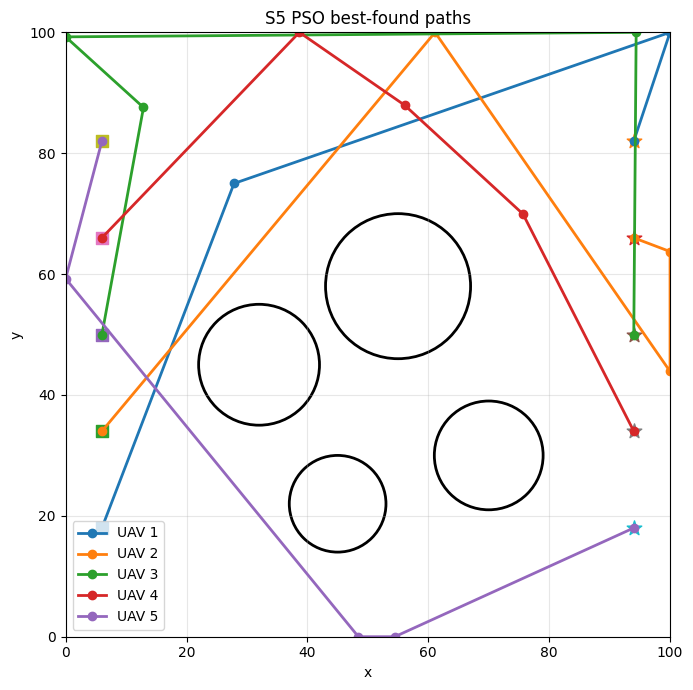

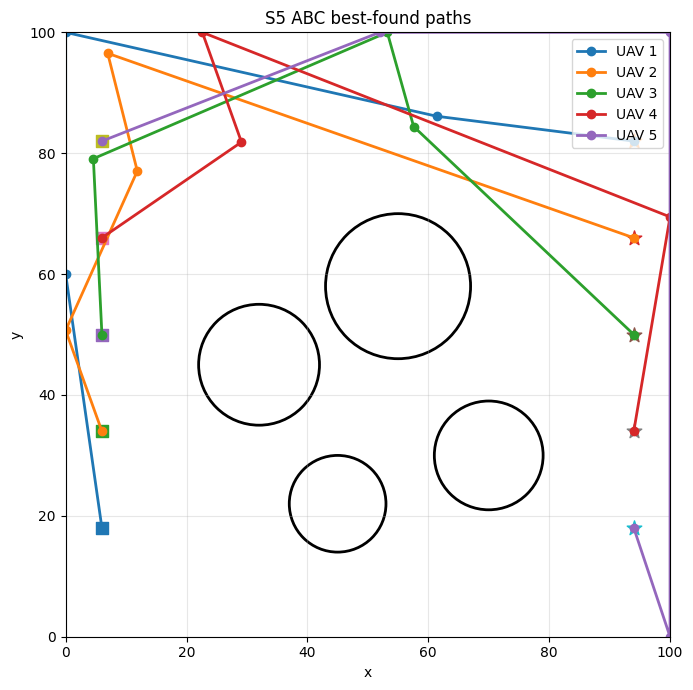

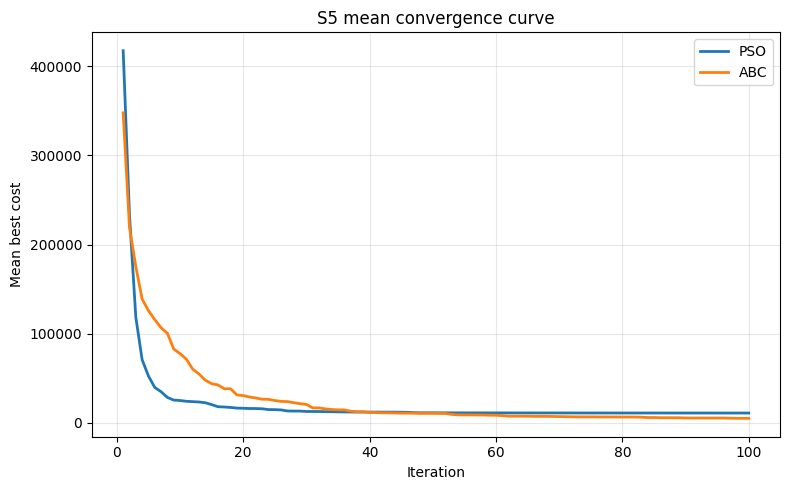

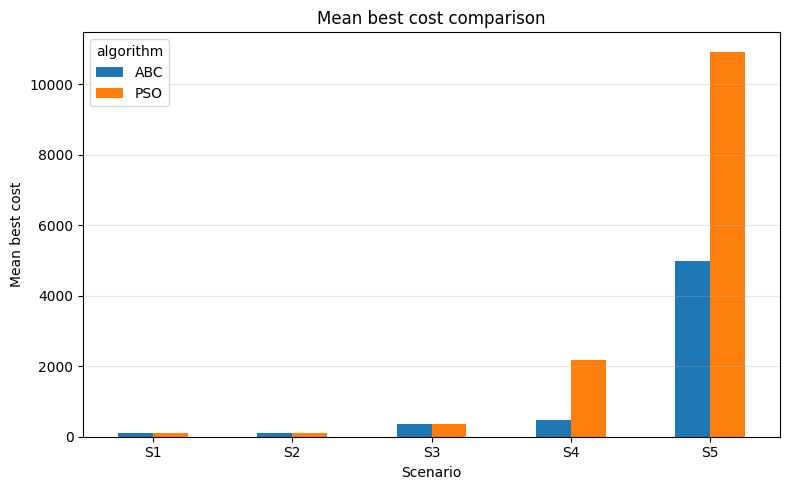

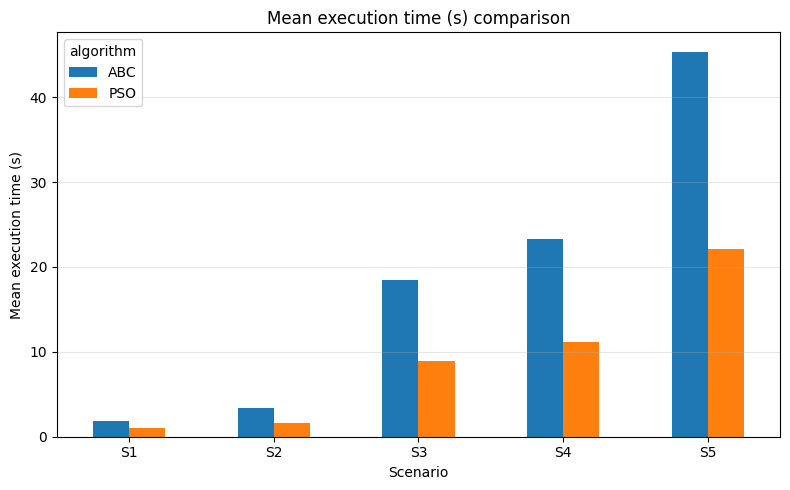

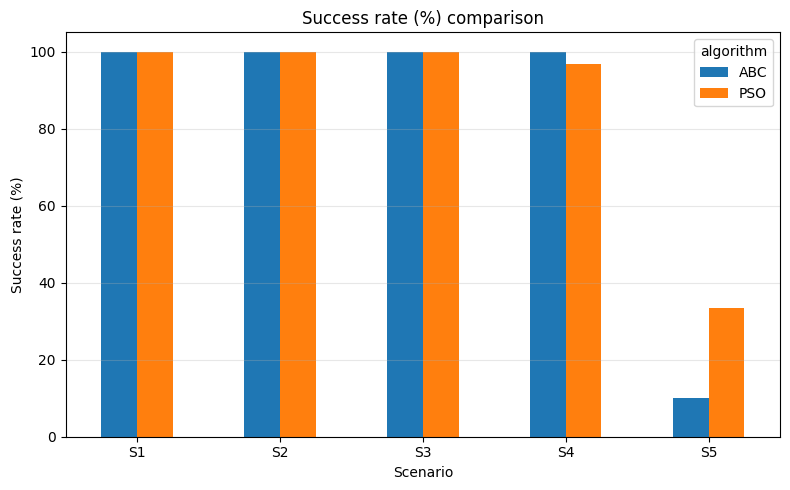

In [9]:
selected_path_figures = []
selected_path_figures.append(plot_best_paths("S5", "PSO"))
selected_path_figures.append(plot_best_paths("S5", "ABC"))

convergence_figure = plot_convergence("S5")
cost_figure = plot_metric_bar("mean_cost", "Mean best cost", "mean_cost_comparison")
time_figure = plot_metric_bar("mean_execution_time", "Mean execution time (s)", "execution_time_comparison")
success_figure = plot_metric_bar("success_rate", "Success rate (%)", "success_rate_comparison")

## 8. Additional Scenario Figures

This cell generates best-path and convergence figures for all scenarios. These figures can be used as additional material or appendix if needed.

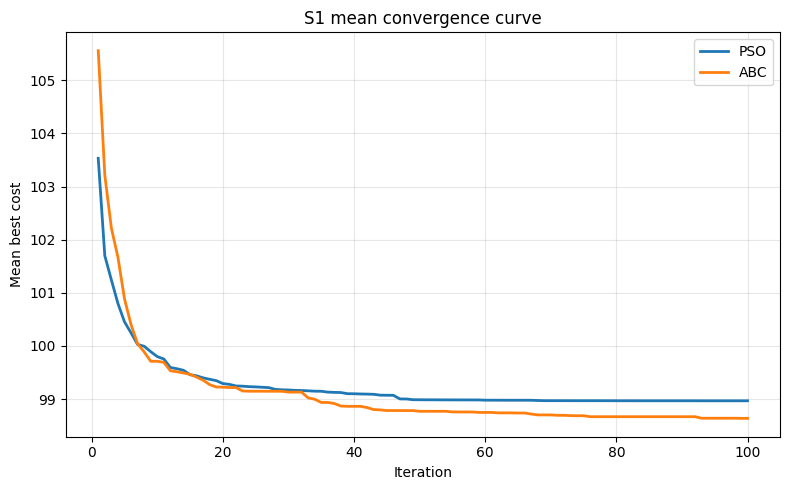

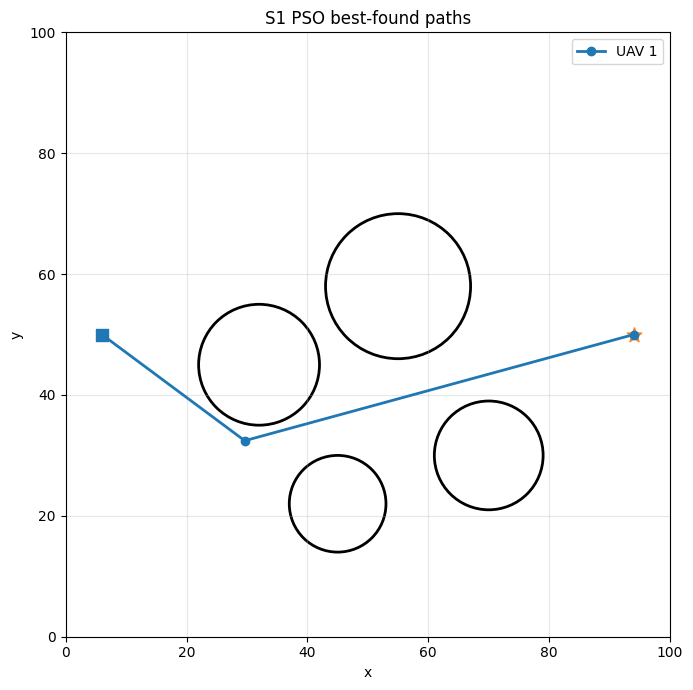

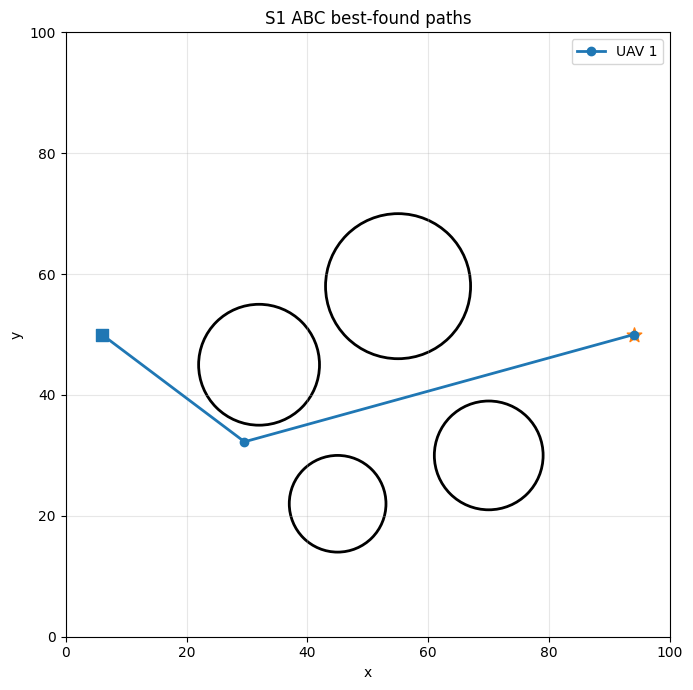

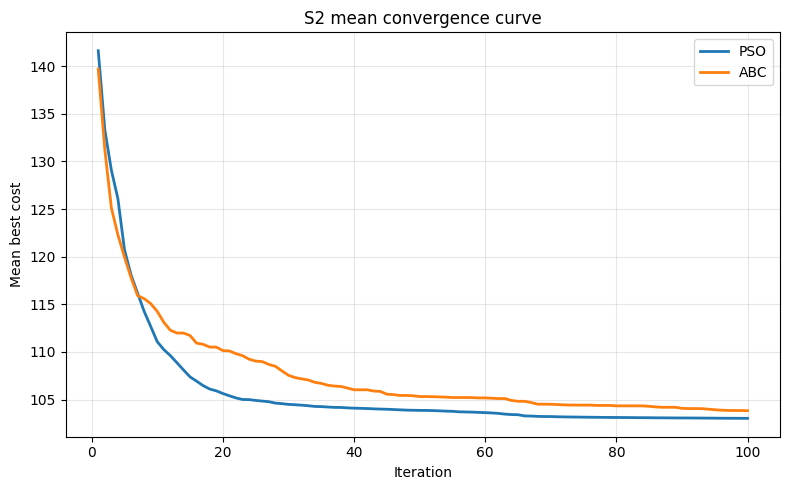

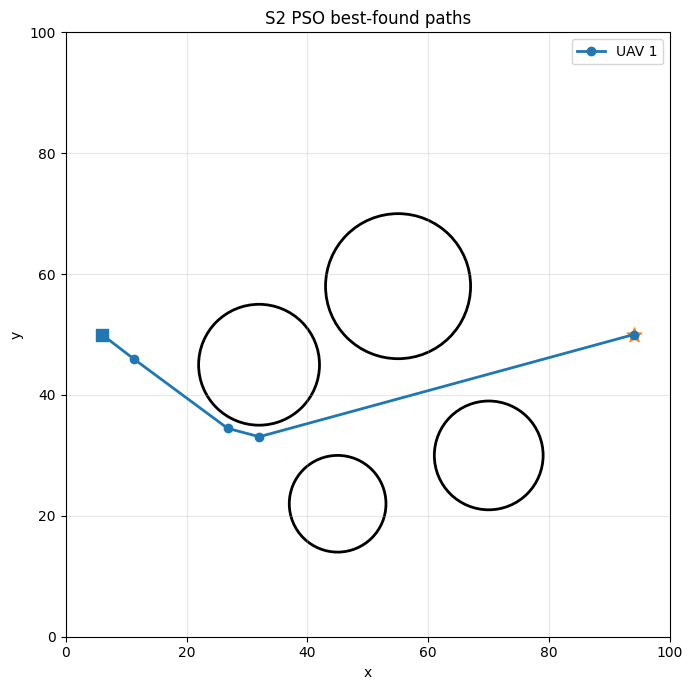

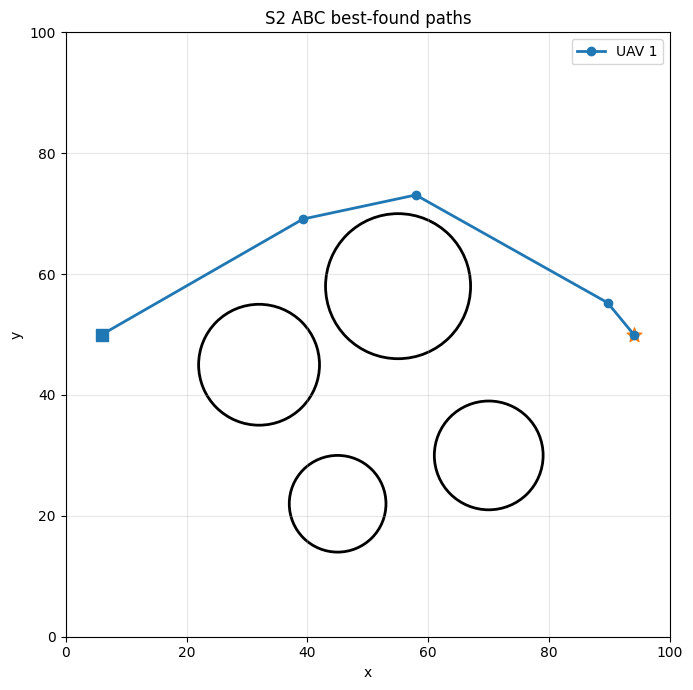

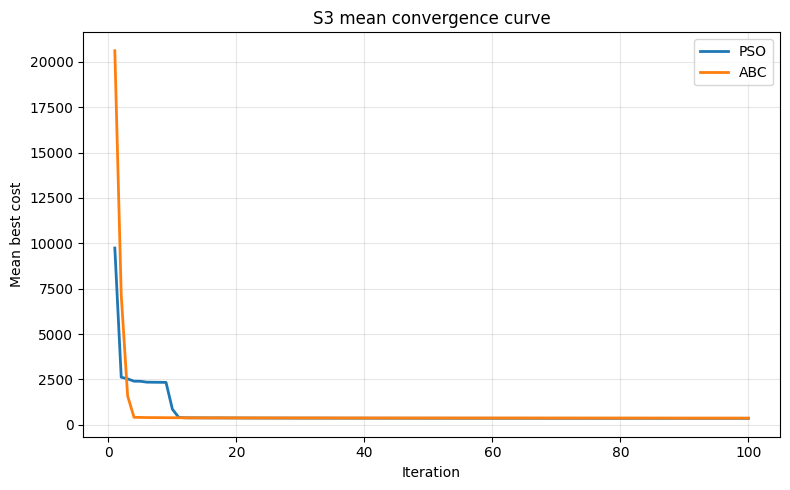

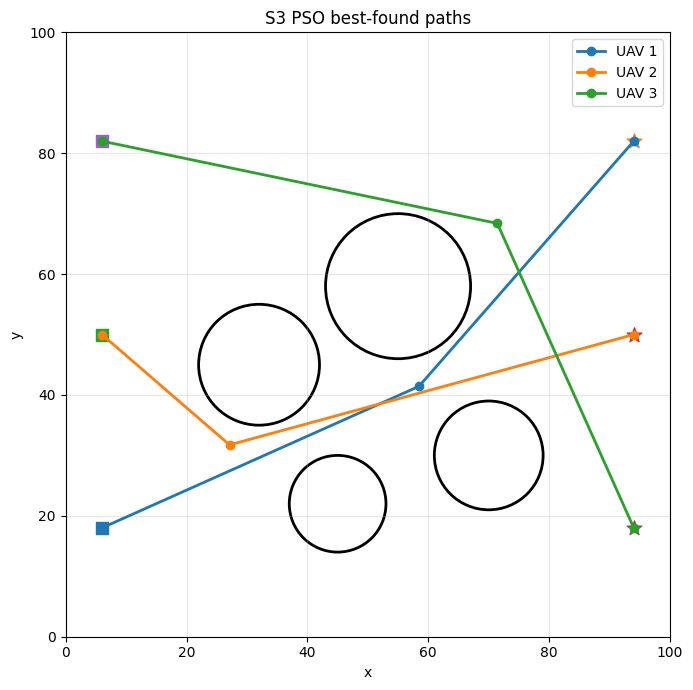

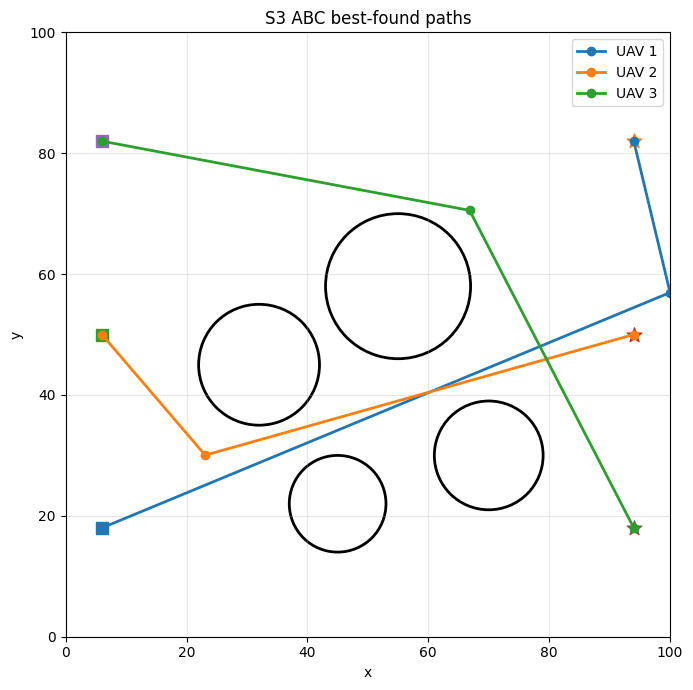

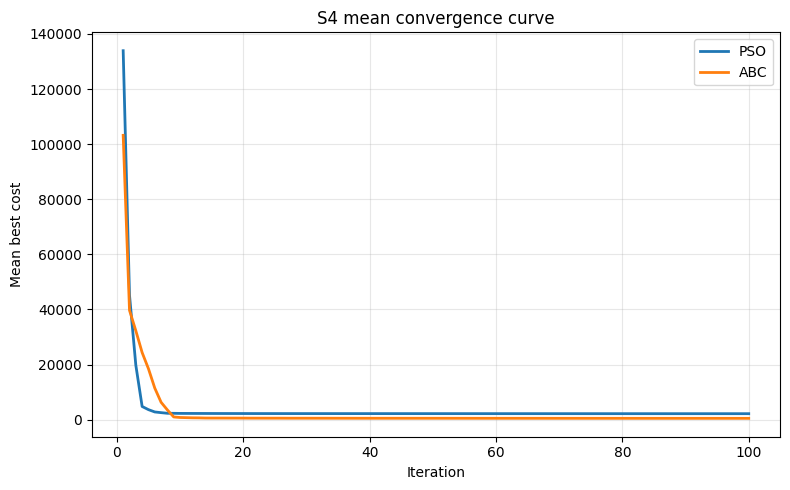

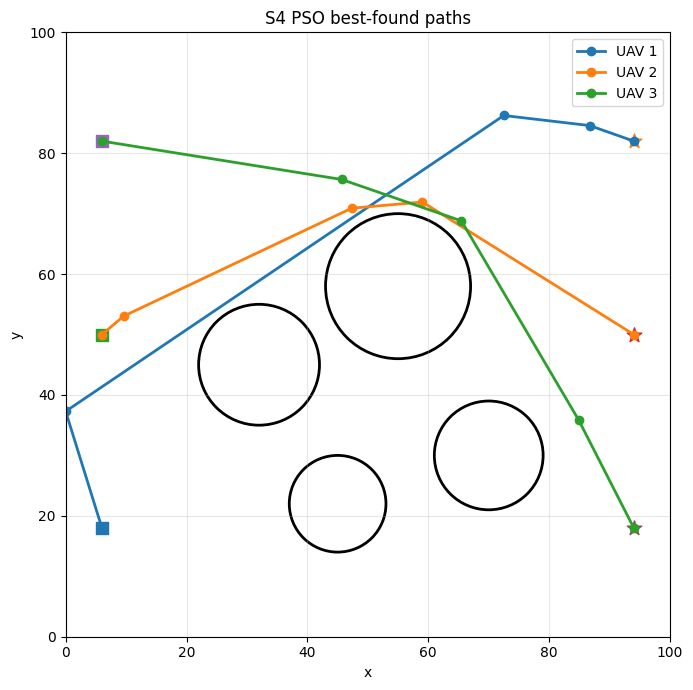

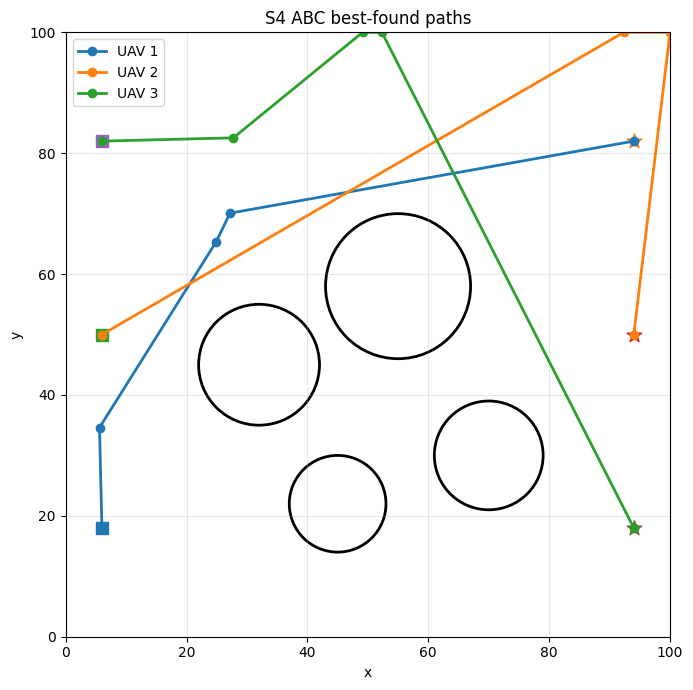

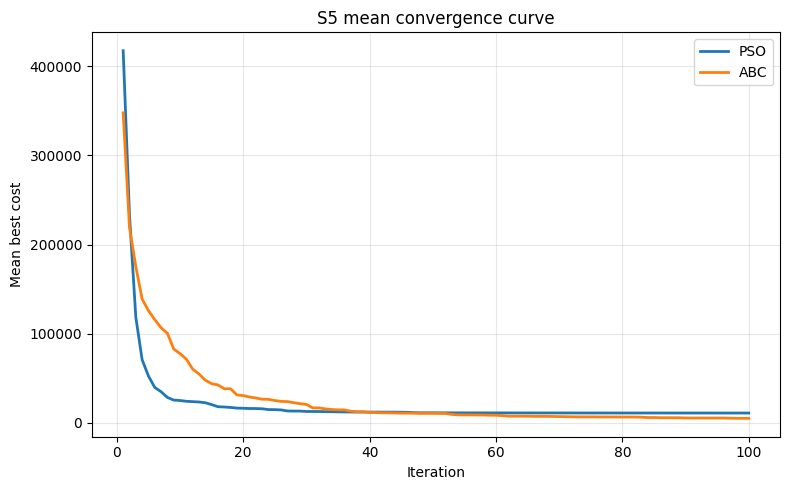

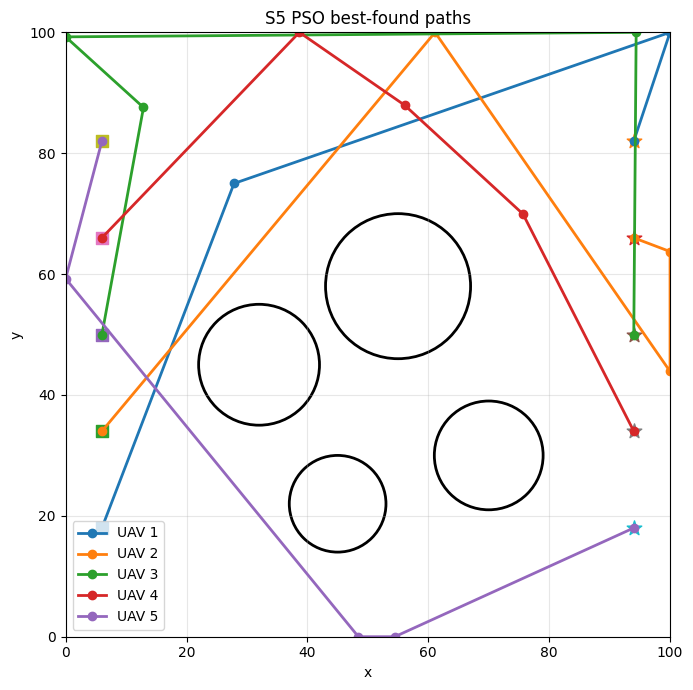

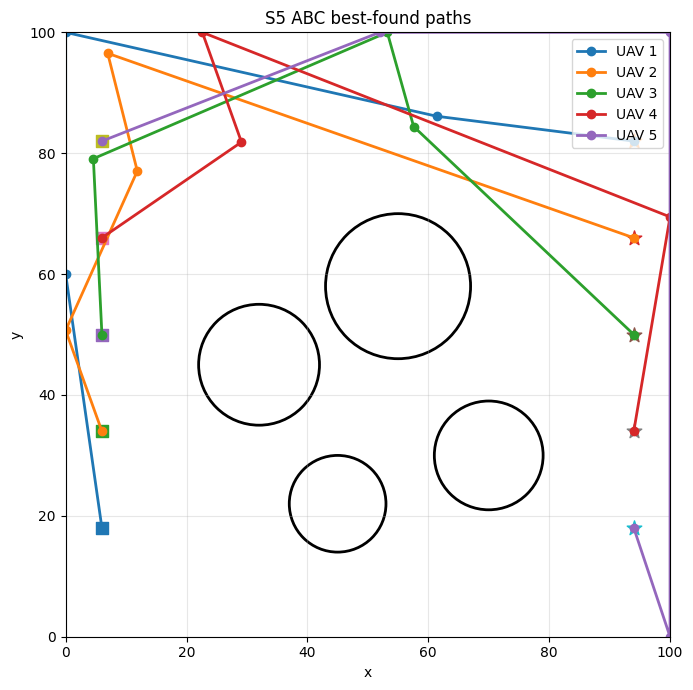

15

In [10]:
all_generated_figures = []

for scenario_cfg in SCENARIOS:
    scenario = scenario_cfg["scenario"]
    all_generated_figures.append(plot_convergence(scenario))
    for algorithm in ["PSO", "ABC"]:
        all_generated_figures.append(plot_best_paths(scenario, algorithm))

len(all_generated_figures)

## 9. Interpretation Support Table

This table identifies which algorithm gives lower mean cost, lower mean path length, and lower mean computation time in each scenario.

In [11]:
comparison_rows = []

for scenario in summary_df["scenario"].unique():
    subset = summary_df[summary_df["scenario"] == scenario]
    cost_winner = subset.loc[subset["mean_cost"].idxmin(), "algorithm"]
    path_winner = subset.loc[subset["mean_path_length"].idxmin(), "algorithm"]
    time_winner = subset.loc[subset["mean_execution_time"].idxmin(), "algorithm"]
    success_winner = subset.loc[subset["success_rate"].idxmax(), "algorithm"]
    comparison_rows.append({
        "scenario": scenario,
        "lower_mean_cost": cost_winner,
        "lower_mean_path_length": path_winner,
        "lower_mean_execution_time": time_winner,
        "higher_success_rate": success_winner
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_path = os.path.join(OUTPUT_DIR, "scenario_winner_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

comparison_df

,scenario,lower_mean_cost,lower_mean_path_length,lower_mean_execution_time,higher_success_rate
0,S1,ABC,ABC,PSO,ABC
1,S2,PSO,PSO,PSO,ABC
2,S3,PSO,PSO,PSO,ABC
3,S4,ABC,ABC,PSO,ABC
4,S5,ABC,ABC,PSO,PSO


## 10. Exported Files

| File | Purpose |
|---|---|
| raw_simulation_results.csv | raw simulation data for each run |
| raw_convergence_history.csv | best cost per iteration for every run |
| summary_results.csv | aggregated results for report tables |
| scenario_winner_summary.csv | compact comparison table |
| figures | report-ready trajectory and convergence figures |
| uav_path_planning_outputs.zip | compressed output archive |

In [12]:
zip_path = "uav_path_planning_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUTPUT_DIR)
            zf.write(full_path, arcname=os.path.join("uav_path_planning_outputs", arcname))

print("Created:", zip_path)
print("Archive size MB:", round(os.path.getsize(zip_path) / (1024 * 1024), 3))

Created: uav_path_planning_outputs.zip
Archive size MB: 2.637


In [13]:
try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print("Download is available when this notebook is executed in Google Colab.")
    print(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>